# Full-Trace Analysis

Each observation is one complete 20-prompt continuous trace (no inter-trial reset).



In [1]:
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

# ── Configuration ──────────────────────────────────────────────────────────
BASE_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / 'data' / 'fulltrace').is_dir())
DATA_DIR  = BASE_DIR / 'data' / 'fulltrace'

FEATURES = [
    'core_power.throttle__mean_rate',
    'core_power.throttle__variance',
    'core_power.throttle__spectral_entropy',
    'core_power.throttle__slope',
]

SHORT = {f: f.split('__')[-1] for f in FEATURES}

SEED = 42
N_PERMUTATIONS = 10_000
N_BOOTSTRAP    = 5_000

print('Configuration OK')
CONDITIONS = ['emotional', 'neutral', 'joyful']
PAIRS = list(combinations(CONDITIONS, 2))
CODES = {'emotional': 'E', 'neutral': 'N', 'joyful': 'J'}
COLORS = {'emotional': '#333333', 'neutral': '#999999', 'joyful': '#d98c00'}

Configuration OK


## §1 — Load data

In [2]:
# Load all *_whole.csv files from the fulltrace directory
whole_csvs = sorted(p for p in DATA_DIR.glob('*_whole.csv') if p.name != 'all_whole.csv')


dfs = [pd.read_csv(p) for p in whole_csvs]
df = pd.concat(dfs, ignore_index=True)

if 'condition' not in df.columns and 'label' in df.columns:
    df['condition'] = df['label']

df['condition'] = df['condition'].replace({'joy': 'joyful', 'independentJ': 'joyful'})

# Deduplicate on run_label — keep first occurrence
dropped = df[df.duplicated(subset='run_label', keep='first')]['run_label'].tolist()
df = df.drop_duplicates(subset='run_label', keep='first').reset_index(drop=True)
if dropped:
    print(f'\nDropped {len(dropped)} duplicate run_labels: {dropped}')

n_e = (df.condition == 'emotional').sum()
n_n = (df.condition == 'neutral').sum()
n_j = (df.condition == 'joyful').sum()
print(df['condition'].value_counts().reindex(CONDITIONS, fill_value=0))
missing = [c for c in CONDITIONS if not (df.condition == c).any()]
if missing:
    raise ValueError(f'Missing conditions: {missing}. Extract their whole-trace CSVs first.')


available = []
for f in FEATURES:
    ok = f in df.columns
    print(f'  {"✓" if ok else "✗"} {SHORT[f]}')
    if ok:
        available.append(f)
FEATURES = available

print('\nData loaded successfully')

condition
emotional    20
neutral      20
joyful       16
Name: count, dtype: int64
  ✓ mean_rate
  ✓ variance
  ✓ spectral_entropy
  ✓ slope

Data loaded successfully


## §2 — Per-feature univariate tests

For each feature and each condition pair (E–N, E–J, N–J), retain the same descriptive statistics, Welch two-sample t-test, Mann–Whitney U test, and Cohen's d. Bonferroni correction covers all feature/pair comparisons.

In [3]:
results = []
for feat in FEATURES:
    for left, right in PAIRS:
        a = df.loc[df.condition == left, feat].dropna().values
        b = df.loc[df.condition == right, feat].dropna().values
        if len(a) < 2 or len(b) < 2:
            raise ValueError(f'Need at least two values for {feat}: {left}/{right}')
        a_mean, a_std = np.mean(a), np.std(a, ddof=1)
        b_mean, b_std = np.mean(b), np.std(b, ddof=1)
        pooled_std = np.sqrt((a_std**2 + b_std**2) / 2)
        t_stat, t_p = ttest_ind(a, b, equal_var=False)
        u_stat, mwu_p = mannwhitneyu(a, b, alternative='two-sided')
        results.append(dict(
            feature=SHORT[feat], left=left, right=right,
            pair=f'{CODES[left]}–{CODES[right]}',
            direction='↑' + CODES[left if a_mean > b_mean else right],
            left_mean=a_mean, left_std=a_std, right_mean=b_mean, right_std=b_std,
            cohens_d=abs(a_mean-b_mean)/pooled_std if pooled_std > 0 else np.nan,
            t_stat=t_stat, t_p=t_p, U=u_stat, mwu_p=mwu_p))
res_df = pd.DataFrame(results)
n_tests = len(results)
res_df['t_p_corr'] = (res_df['t_p'] * n_tests).clip(upper=1.0)
res_df['mwu_p_corr'] = (res_df['mwu_p'] * n_tests).clip(upper=1.0)
print(f'Per-feature tests (n_E={n_e}, n_N={n_n}, n_J={n_j}, Bonferroni k={n_tests})')
print(res_df.to_string(index=False))

Per-feature tests (n_E=20, n_N=20, n_J=16, Bonferroni k=12)
         feature      left   right pair direction    left_mean     left_std   right_mean    right_std  cohens_d    t_stat          t_p     U    mwu_p  t_p_corr  mwu_p_corr
       mean_rate emotional neutral  E–N        ↑E 1.225696e+04 6.599476e+02 1.169595e+04 7.232990e+02  0.810301  2.562398 1.451818e-02 308.0 0.003639  0.174218    0.043666
       mean_rate emotional  joyful  E–J        ↑J 1.225696e+04 6.599476e+02 1.281065e+04 2.049510e+02  1.133132 -3.544516 1.694594e-03  57.0 0.001102  0.020335    0.013221
       mean_rate   neutral  joyful  N–J        ↑J 1.169595e+04 7.232990e+02 1.281065e+04 2.049510e+02  2.096940 -6.570345 1.120564e-06  10.0 0.000002  0.000013    0.000023
        variance emotional neutral  E–N        ↑E 3.709028e+13 8.520665e+12 3.616646e+13 8.533050e+12  0.108342  0.342608 7.337812e-01 210.0 0.797197  1.000000    1.000000
        variance emotional  joyful  E–J        ↑J 3.709028e+13 8.520665e+12 3.93

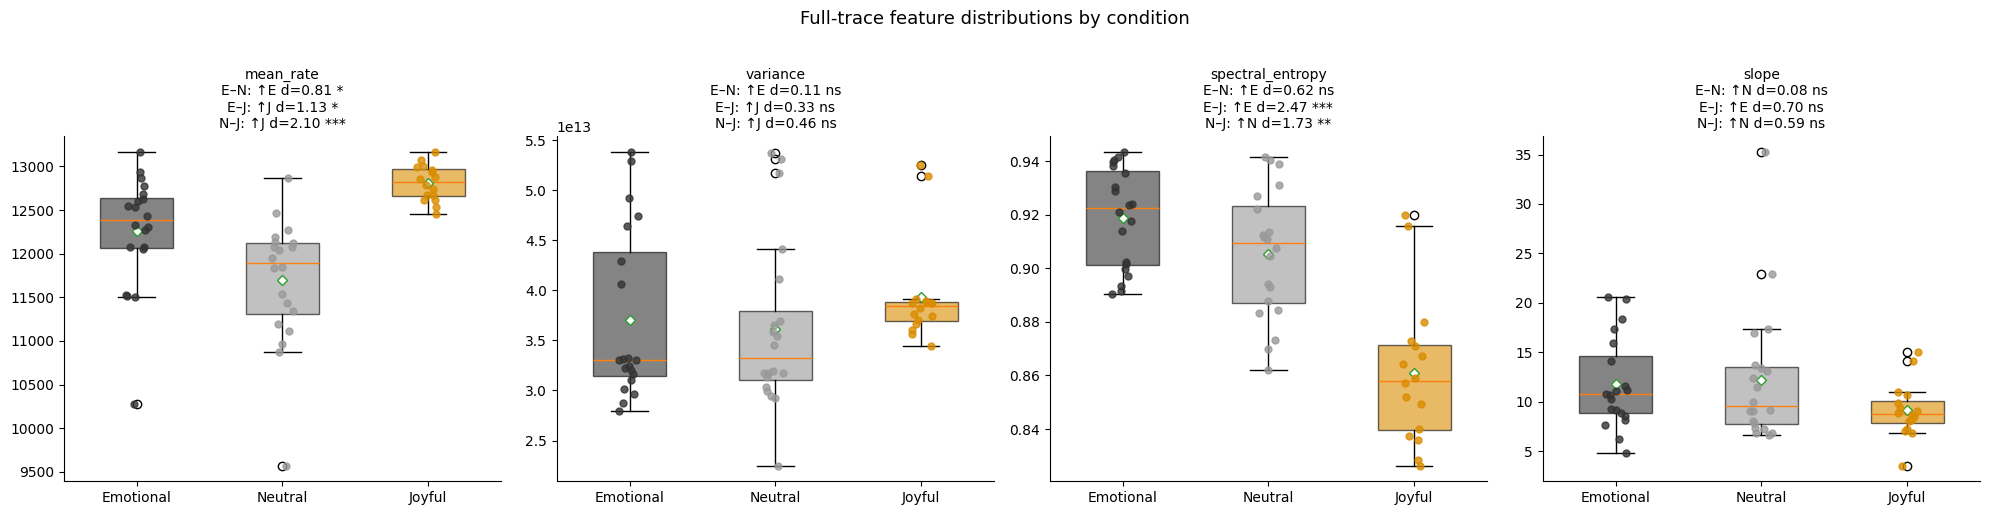

In [5]:
n_feat = len(FEATURES)
fig, axes = plt.subplots(1, n_feat, figsize=(5 * n_feat, 5), squeeze=False)
rng_j = np.random.default_rng(SEED)
for ax, feat in zip(axes[0], FEATURES):
    groups = [df.loc[df.condition == c, feat].dropna().values for c in CONDITIONS]
    positions = np.arange(len(CONDITIONS))
    bp = ax.boxplot(groups, positions=positions, widths=0.5, patch_artist=True,
                    showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markersize=5))
    for pos, cond, vals, box in zip(positions, CONDITIONS, groups, bp['boxes']):
        box.set_facecolor(COLORS[cond])
        box.set_alpha(0.6)
        ax.scatter(pos + rng_j.uniform(-0.08, 0.08, len(vals)), vals,
                   color=COLORS[cond], s=25, zorder=5, alpha=0.8)
    annotations = []
    for _, r in res_df[res_df.feature == SHORT[feat]].iterrows():
        sig = '***' if r.mwu_p_corr < 0.001 else '**' if r.mwu_p_corr < 0.01 else '*' if r.mwu_p_corr < 0.05 else 'ns'
        annotations.append(f'{r.pair}: {r.direction} d={r.cohens_d:.2f} {sig}')
    ax.set_title(SHORT[feat] + '\n' + '\n'.join(annotations), fontsize=10)
    ax.set_xticks(positions)
    ax.set_xticklabels([c.title() for c in CONDITIONS])
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Full-trace feature distributions by condition', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## §2b — Per-feature intra/inter group distances

For each feature and condition pair, compute mean within-group distances, mean cross-condition distance, and the inter/intra ratio using the same unique within-group pairs and all cross-group pairs as before.

In [6]:
dist_1d_results = []
for feat in FEATURES:
    for left, right in PAIRS:
        a = df.loc[df.condition == left, feat].dropna().values
        b = df.loc[df.condition == right, feat].dropna().values
        intra_a = np.array([abs(x-y) for x, y in combinations(a, 2)])
        intra_b = np.array([abs(x-y) for x, y in combinations(b, 2)])
        inter = np.abs(a[:, None] - b[None, :]).ravel()
        mean_intra = np.concatenate([intra_a, intra_b]).mean()
        r = res_df[(res_df.feature == SHORT[feat]) & (res_df.left == left) & (res_df.right == right)].iloc[0]
        dist_1d_results.append(dict(
            feature=SHORT[feat], left=left, right=right, pair=r.pair, direction=r.direction,
            intra_left=intra_a.mean(), intra_right=intra_b.mean(),
            intra_avg=mean_intra, inter=inter.mean(),
            ratio=inter.mean()/mean_intra if mean_intra > 0 else np.nan))
dist_1d_df = pd.DataFrame(dist_1d_results)
print(dist_1d_df.to_string(index=False))
print('Inter/Intra > 1: cross-condition pairs are farther apart on average.')
print('Inter/Intra ≈ 1: similar mean within- and cross-condition distances.')

         feature      left   right pair direction   intra_left  intra_right    intra_avg        inter    ratio
       mean_rate emotional neutral  E–N        ↑E 7.039544e+02 7.807010e+02 7.423277e+02 8.670572e+02 1.168025
       mean_rate emotional  joyful  E–J        ↑J 7.039544e+02 2.425709e+02 5.253543e+02 6.320258e+02 1.203047
       mean_rate   neutral  joyful  N–J        ↑J 7.807010e+02 2.425709e+02 5.723926e+02 1.126173e+03 1.967484
        variance emotional neutral  E–N        ↑E 9.270381e+12 9.235180e+12 9.252780e+12 8.958595e+12 0.968206
        variance emotional  joyful  E–J        ↑J 9.270381e+12 4.629287e+12 7.473828e+12 8.491508e+12 1.136166
        variance   neutral  joyful  N–J        ↑J 9.235180e+12 4.629287e+12 7.452253e+12 8.223112e+12 1.103440
spectral_entropy emotional neutral  E–N        ↑E 2.173670e-02 2.813269e-02 2.493470e-02 2.634401e-02 1.056520
spectral_entropy emotional  joyful  E–J        ↑E 2.173670e-02 3.069162e-02 2.520312e-02 5.960218e-02 2.364873
s

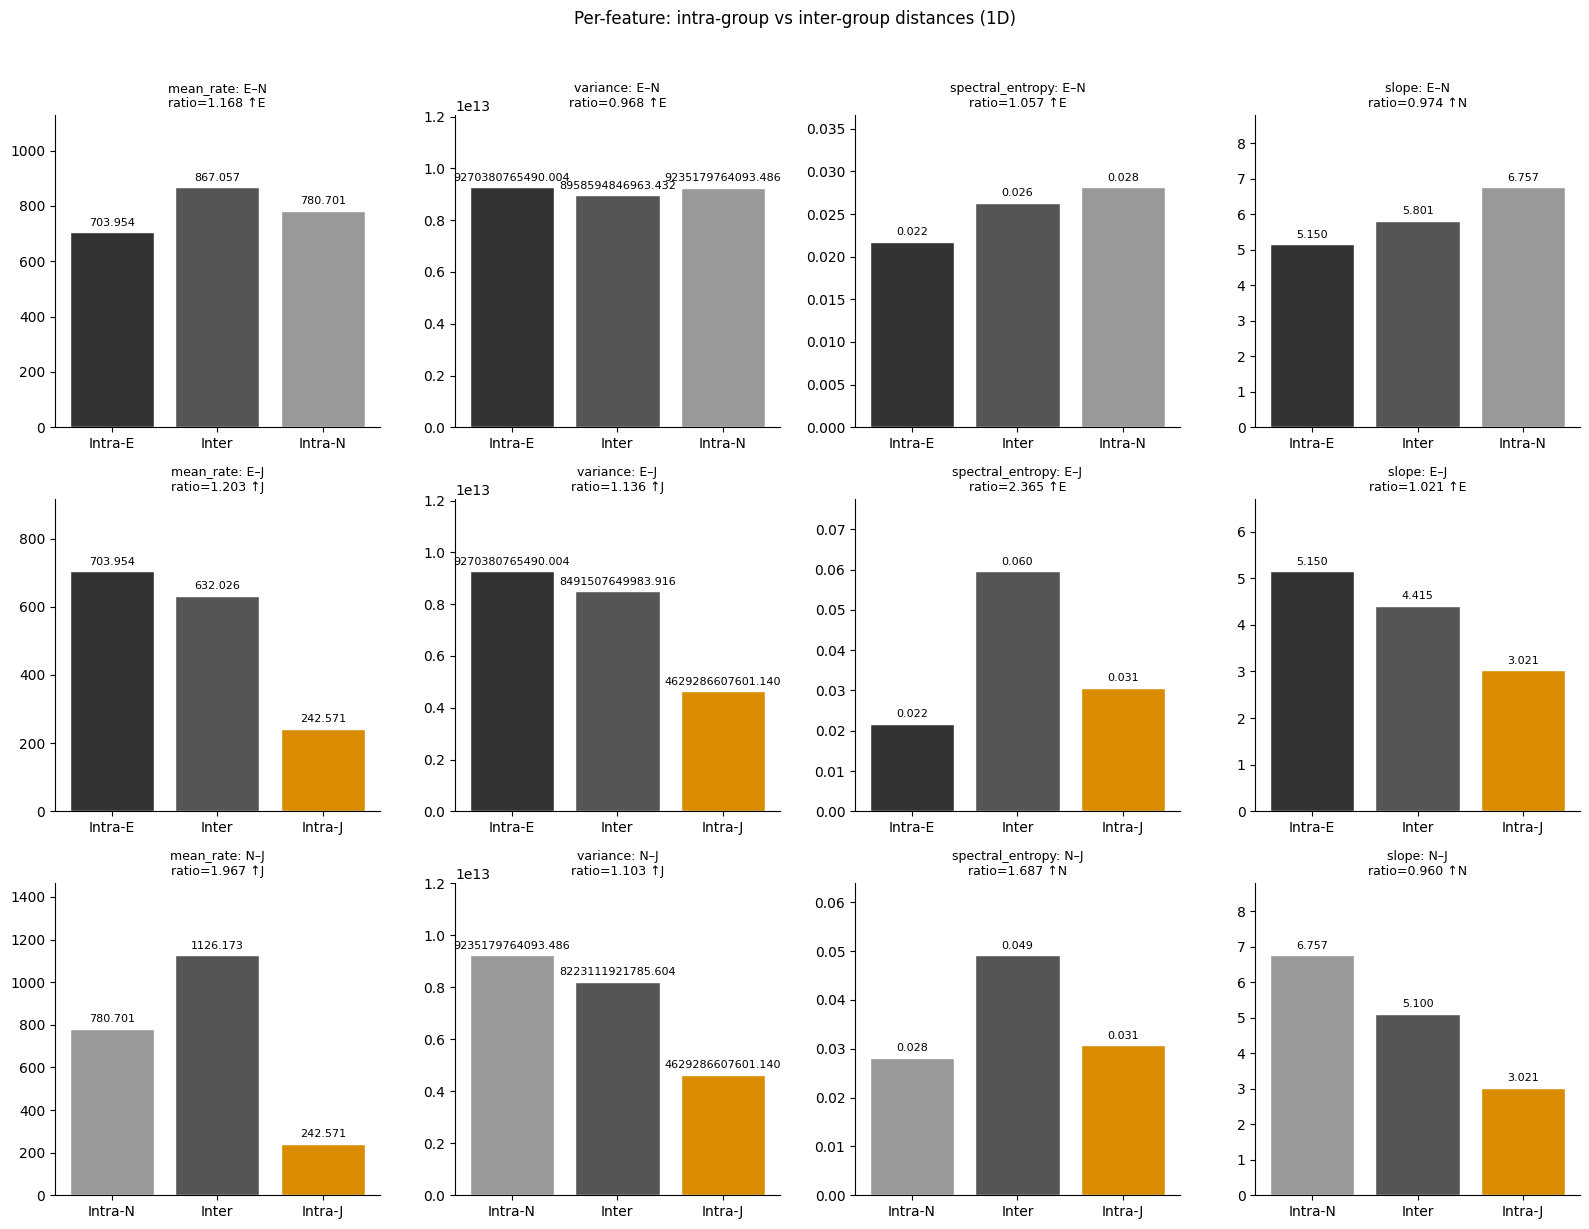

In [8]:
# Same intra/inter bars, with a row for each condition pair.
fig, axes = plt.subplots(len(PAIRS), len(FEATURES),
                         figsize=(4 * len(FEATURES), 4 * len(PAIRS)), squeeze=False)
for row_idx, (left, right) in enumerate(PAIRS):
    for col_idx, feat in enumerate(FEATURES):
        ax = axes[row_idx, col_idx]
        row = dist_1d_df[(dist_1d_df.feature == SHORT[feat]) &
                         (dist_1d_df.left == left) & (dist_1d_df.right == right)].iloc[0]
        vals = [row.intra_left, row.inter, row.intra_right]
        bars = ax.bar(range(3), vals, color=[COLORS[left], '#555555', COLORS[right]], edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, val+max(vals)*0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        ax.set_xticks(range(3))
        ax.set_xticklabels([f'Intra-{CODES[left]}', 'Inter', f'Intra-{CODES[right]}'])
        ax.set_title(f'{row.feature}: {row.pair}\nratio={row.ratio:.3f} {row.direction}', fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_ylim(0, max(vals)*1.3 if max(vals) > 0 else 1)
fig.suptitle('Per-feature: intra-group vs inter-group distances (1D)', y=1.02)
plt.tight_layout()
plt.show()

## §4 — Summary

In [9]:
print('FULL-TRACE ANALYSIS SUMMARY')
print(f'Traces: {n_e} emotional, {n_n} neutral, {n_j} joyful')
print(f'Features: {len(FEATURES)}')
print('PER-FEATURE RESULTS (Bonferroni-corrected):')
print(res_df[['feature', 'pair', 'direction', 'cohens_d', 't_p_corr', 'mwu_p_corr']].to_string(index=False))
print('PER-FEATURE DISTANCE RATIOS (inter/intra):')
print(dist_1d_df[['feature', 'pair', 'ratio', 'direction']].to_string(index=False))

FULL-TRACE ANALYSIS SUMMARY
Traces: 20 emotional, 20 neutral, 16 joyful
Features: 4
PER-FEATURE RESULTS (Bonferroni-corrected):
         feature pair direction  cohens_d  t_p_corr  mwu_p_corr
       mean_rate  E–N        ↑E  0.810301  0.174218    0.043666
       mean_rate  E–J        ↑J  1.133132  0.020335    0.013221
       mean_rate  N–J        ↑J  2.096940  0.000013    0.000023
        variance  E–N        ↑E  0.108342  1.000000    1.000000
        variance  E–J        ↑J  0.325793  1.000000    0.806005
        variance  N–J        ↑J  0.456783  1.000000    0.231451
spectral_entropy  E–N        ↑E  0.616891  0.707369    1.000000
spectral_entropy  E–J        ↑E  2.467143  0.000002    0.000069
spectral_entropy  N–J        ↑N  1.728911  0.000198    0.001155
           slope  E–N        ↑N  0.081548  1.000000    1.000000
           slope  E–J        ↑E  0.698568  0.482577    0.602905
           slope  N–J        ↑N  0.590751  0.932169    1.000000
PER-FEATURE DISTANCE RATIOS (inter/intra

## TTR analysis

In [10]:
import json

def ttr(text):
    tokens = text.lower().split()
    return len(set(tokens)) / len(tokens) if tokens else 0

ttr_groups = {}
for cond in CONDITIONS:
    path = BASE_DIR / 'prompts' / '20base' / f'independent{CODES[cond]}.json'
    prompts = json.loads(path.read_text())
    ttr_groups[cond] = [ttr(p['instructions']) for p in prompts]
print('Type-to-Token Ratio (word-level)')
for cond, vals in ttr_groups.items():
    print(f'{cond.title():10s} n={len(vals):3d} mean={np.mean(vals):.4f} std={np.std(vals):.4f}')
ttr_results = []
for left, right in PAIRS:
    t, p_t = ttest_ind(ttr_groups[left], ttr_groups[right])
    u, p_u = mannwhitneyu(ttr_groups[left], ttr_groups[right], alternative='two-sided')
    ttr_results.append(dict(pair=f'{CODES[left]}–{CODES[right]}', t=t, t_p=p_t, U=u, mwu_p=p_u,
                            t_p_corr=min(p_t*len(PAIRS), 1), mwu_p_corr=min(p_u*len(PAIRS), 1)))
print(pd.DataFrame(ttr_results).to_string(index=False))
print('Corrected TTR p-values use Bonferroni across the three condition pairs.')

Type-to-Token Ratio (word-level)
Emotional  n= 20 mean=0.6723 std=0.0398
Neutral    n= 20 mean=0.6044 std=0.0367
Joyful     n= 20 mean=0.5988 std=0.0465
pair        t      t_p     U    mwu_p  t_p_corr  mwu_p_corr
 E–N 5.469825 0.000003 358.0 0.000020  0.000009    0.000061
 E–J 5.241234 0.000006 363.0 0.000011  0.000019    0.000033
 N–J 0.412451 0.682326 201.0 0.989208  1.000000    1.000000
Corrected TTR p-values use Bonferroni across the three condition pairs.
